# 제주 통과형 동 EDA
STEP 1 전처리·파생변수 + EDA + 미스매치 지수. CSV 5개와 같은 폴더에서 위에서부터 순서대로 실행하세요.

면적.csv는 첫 실행 때 자동 생성되며, 면적_km2를 채워 다시 실행하면 숙박밀도가 계산됩니다.

## 0. 설정

In [1]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

plt.rcParams['font.family'] = 'Malgun Gothic'   # Mac: 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
pd.options.display.float_format = '{:,.2f}'.format
pd.options.display.width = 200

## 1. 불러오기 + 정리 (중복 제거 안 함: 소비 파일은 더 세부 단위의 행이라 같은 값이 우연히 반복됨)

In [2]:
v = pd.read_csv('제주 지역별 방문객(읍면동).csv')
s = pd.read_csv('제주 지역별 소비.csv')
c = pd.read_csv('제주 지역별 차량 도착 수.csv')
p = pd.read_csv('제주_지역별_인기_장소.csv')

for df, col in [(v,'기준연월'), (s,'기준연월'), (c,'주행연월(YYYYMM)'), (p,'주행일자(YYYYMM)')]:
    df['월'] = pd.to_datetime(df[col].astype(str), format='%Y%m')

v = v.rename(columns={'내국인 방문객수':'내국인방문','외국인 방문객수':'외국인방문','총 방문객수 (내국인+외국인)':'총방문'})
s = s.rename(columns={'소비금액(원)':'소비금액'})
c = c.rename(columns={'도착건수':'차량도착'})
p = p.rename(columns={'카테고리 3단계':'카테고리','관광객 도착 수':'관광객도착','도민 도착 수':'도민도착'})

# 품질 점검
for name, df in [('방문객',v), ('소비',s), ('차량',c), ('인기장소',p)]:
    print(f"{name:6} 행 {len(df):>8,} | 결측 {df.isna().sum().sum()} | {df['월'].min():%Y-%m}~{df['월'].max():%Y-%m} | 읍면동 {df['읍면동명'].nunique()}")

방문객    행    1,548 | 결측 0 | 2023-01~2025-12 | 읍면동 43
소비     행  319,123 | 결측 0 | 2023-01~2025-12 | 읍면동 43
차량     행    1,548 | 결측 0 | 2023-01~2025-12 | 읍면동 43
인기장소   행  846,064 | 결측 0 | 2023-01~2025-12 | 읍면동 43


## 2. 월×읍면동 패널 (조인 키는 읍면동명: 코드는 파일마다 자릿수가 다름)

In [3]:
st = s[s['관광객구분'] != '도민']
cons = st.groupby(['월','읍면동명']).agg(관광객소비=('소비금액','sum'), 관광객이용건수=('이용건수','sum'))
cons_biz = st.pivot_table(index=['월','읍면동명'], columns='업종명', values='소비금액', aggfunc='sum', fill_value=0).add_prefix('소비_')
cons_loc = s[s['관광객구분']=='도민'].groupby(['월','읍면동명'])['소비금액'].sum().rename('도민소비')

TREK = ['오름','명산','폭포/계곡','자연휴양림','공원','도립공원','국립공원','전망대','드라이브코스']
EXP  = ['체험농가','체험학습','승마장','낚시','수상해양스포츠','관광농원','목장','농장/농원','레저/스포츠기타','여행/레저기타']
p['테마'] = p['카테고리'].map(lambda x: '트레킹' if x in TREK else '체험' if x in EXP else '기타')
pt = p.pivot_table(index=['월','읍면동명'], columns='테마', values='관광객도착', aggfunc='sum', fill_value=0).add_prefix('관광객도착_')
pt['관광객도착_전체'] = p.groupby(['월','읍면동명'])['관광객도착'].sum()
pt['도민도착_전체']   = p.groupby(['월','읍면동명'])['도민도착'].sum()
pt['도착건수_전체']   = p.groupby(['월','읍면동명'])['도착건수'].sum()

panel = (v.set_index(['월','읍면동명'])[['내국인방문','외국인방문','총방문']]
           .join(c.set_index(['월','읍면동명'])['차량도착'])
           .join(cons).join(cons_loc).join(cons_biz).join(pt)).reset_index()
area_name = s[['읍면동명','지역명']].drop_duplicates().set_index('읍면동명')['지역명']
panel['지역명'] = panel['읍면동명'].map(area_name)
panel['시'] = panel['지역명'].str.split().str[0]
assert len(panel) == 36*43 and panel.isna().sum().sum() == 0
print('panel', panel.shape, '결측 0')

panel (1548, 22) 결측 0


## 3. 읍면동 단위 파생변수 (STEP 1)

In [4]:
sumcols = ['총방문','내국인방문','외국인방문','차량도착','관광객소비','관광객이용건수','도민소비',
           '관광객도착_트레킹','관광객도착_체험','관광객도착_기타','관광객도착_전체','도민도착_전체','도착건수_전체']
dong = panel.groupby(['시','지역명','읍면동명'])[sumcols].sum().reset_index()

# (1) 관광객 유입 집중도
dong['관광객비중']  = dong['관광객도착_전체'] / dong['도착건수_전체']                   # 그 동 도착 중 관광객 비율
dong['유입집중도']  = dong['관광객도착_전체'] / dong['관광객도착_전체'].sum()           # 제주 전체 관광객 도착 중 이 동의 몫

# (2) 숙박시설 수 (+ 면적이 있으면 밀도)
LODG = ['펜션','호텔','콘도/리조트','게스트하우스','민박']
lod = p[p['카테고리'].isin(LODG)].drop_duplicates(['목적지명','목적지주소'])
dong = dong.merge(lod.groupby('읍면동명').size().rename('숙박시설수'), on='읍면동명', how='left')
if os.path.exists('면적.csv') and pd.read_csv('면적.csv')['면적_km2'].notna().all():
    dong = dong.merge(pd.read_csv('면적.csv'), on='읍면동명', how='left')
    dong['숙박밀도'] = dong['숙박시설수'] / dong['면적_km2']
else:
    pd.DataFrame({'읍면동명': sorted(dong['읍면동명']), '면적_km2': np.nan}).to_csv('면적.csv', index=False, encoding='utf-8-sig')
    print("면적.csv 생성: 면적_km2를 채우고 다시 실행하면 숙박밀도가 계산됩니다")

# (3) 상권: 지오코딩 전 임시 지표 (상권성 카테고리 장소 수)
COMM = ['재래시장','대형마트','대형슈퍼','쇼핑기타','다이소']
com = p[p['카테고리'].isin(COMM)].drop_duplicates(['목적지명','목적지주소'])
dong = dong.merge(com.groupby('읍면동명').size().rename('상권후보장소수'), on='읍면동명', how='left')

# (4) 주차 인프라 = 총 주차구획수 ÷ 주차장 수 (공영만, 서귀포 데이터 희박)
pk = pd.read_csv('전국주차장정보표준데이터.csv', encoding='cp949', low_memory=False)
pk = pk[pk['제공기관명'].fillna('').str.contains('제주')].copy()
p['법정'] = p['목적지주소'].str.extract(r'(?:제주시|서귀포시)\s+(\S+)')[0]
cw = (p.groupby(['법정','읍면동명']).size().rename('n').reset_index()
        .sort_values('n', ascending=False).drop_duplicates('법정').set_index('법정')['읍면동명'])
def from_jibun(a):
    m = re.search(r'(?:제주시|서귀포시)\s+(\S+)', a) if isinstance(a, str) else None
    return m.group(1) if m else None
def from_road(a):
    if not isinstance(a, str): return None
    m = re.search(r'\((\S+?)\)', a)
    if m and re.search(r'(동|읍|면|리)$', m.group(1)): return m.group(1).split(',')[0]
    m = re.search(r'(?:제주시|서귀포시)\s+(\S+[읍면])\s', a)
    return m.group(1) if m else None
pk['법정'] = pk['소재지지번주소'].map(from_jibun).fillna(pk['소재지도로명주소'].map(from_road))
pk['읍면동명'] = pk['법정'].map(cw)
pk.loc[pk['읍면동명'].isna() & pk['법정'].isin(set(p['읍면동명'])), '읍면동명'] = pk['법정']
ok = pk['위도'].between(33.0, 34.0) & pk['경도'].between(126.0, 127.1)
lab, todo = pk[pk['읍면동명'].notna() & ok], pk[pk['읍면동명'].isna() & ok]
dist, idx = NearestNeighbors(n_neighbors=1).fit(lab[['위도','경도']].values).kneighbors(todo[['위도','경도']].values)
pk.loc[todo.index, '읍면동명'] = np.where(dist[:,0]*100 < 2, lab['읍면동명'].values[idx[:,0]], None)
park = (pk.dropna(subset=['읍면동명']).groupby('읍면동명')
          .agg(주차장수=('주차장관리번호','count'), 총주차구획수=('주차구획수','sum')).reset_index())
park['주차인프라'] = park['총주차구획수'] / park['주차장수']
dong = dong.merge(park, on='읍면동명', how='left')
print(f"주차장 동 배정 {pk['읍면동명'].notna().sum()}/{len(pk)}, 주차 결측 동:", dong[dong['주차장수'].isna()]['읍면동명'].tolist())

# (5) 통과지수: 트래픽 순위 - 소비 순위 (클수록 '차는 많은데 돈은 덜 쓰는' 동)
dong['건당소비']   = dong['관광객소비'] / dong['관광객이용건수']
dong['도착당소비'] = dong['관광객소비'] / dong['차량도착']
rk = lambda x: x.rank(pct=True)
dong['통과지수'] = rk(dong['차량도착']) - rk(dong['관광객소비'])            # 방법1: 순위 차이 (클수록 통과형)
b, a = np.polyfit(np.log(dong['차량도착']), np.log(dong['관광객소비']), 1)  # 방법2: 트래픽으로 예상한 소비 대비 실제
dong['소비잔차'] = np.log(dong['관광객소비']) - (a + b*np.log(dong['차량도착']))  # 음수일수록 '예상보다 덜 쓰는' 동
dong['트레킹체험비중'] = (dong['관광객도착_트레킹'] + dong['관광객도착_체험']) / dong['관광객도착_전체']
# 통과형 후보: 예상보다 소비가 적고(잔차<-0.3), 도민 생활 이동이 아니라 관광객 비중이 높은(>=40%) 동. 임계값은 조정 가능
dong['통과후보'] = (dong['소비잔차'] < -0.3) & (dong['관광객비중'] >= 0.4)
print(f'소비~트래픽 로그회귀: 기울기 {b:.2f}, R² {np.corrcoef(np.log(dong["차량도착"]), np.log(dong["관광객소비"]))[0,1]**2:.2f}')
panel.to_csv('panel.csv', index=False, encoding='utf-8-sig'); dong.to_csv('dong.csv', index=False, encoding='utf-8-sig')

면적.csv 생성: 면적_km2를 채우고 다시 실행하면 숙박밀도가 계산됩니다
주차장 동 배정 1648/1657, 주차 결측 동: ['영천동', '예래동', '정방동', '천지동']
소비~트래픽 로그회귀: 기울기 0.65, R² 0.69


## 4. EDA ① 시계열: 방문객 / 소비 / 차량

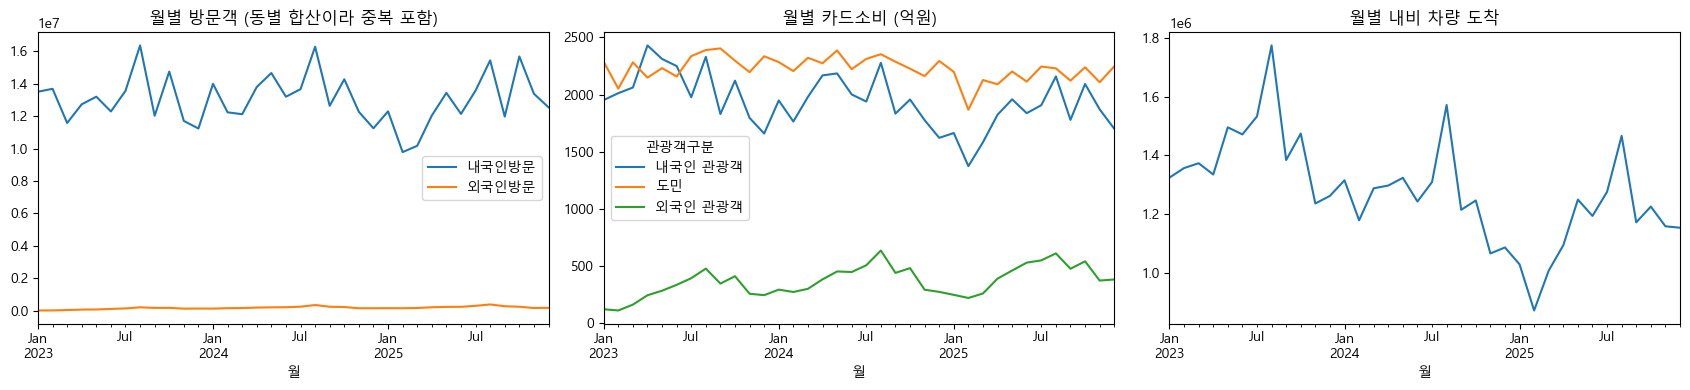

      내국인방문  외국인방문  차량도착  관광객소비
월                              
2024   0.02   0.87 -0.11   0.00
2025  -0.05   0.11 -0.08  -0.05
             총방문              관광객소비
월                                  
1  13,374,428.00 207,677,609,137.00
2  12,018,309.00 191,939,856,595.00
3  11,421,057.00 211,698,272,013.00
4  13,022,209.00 248,078,563,692.00
5  13,946,552.00 255,178,756,661.00
6  12,738,158.00 246,783,475,616.00
7  13,837,493.00 242,543,219,281.00
8  16,350,726.00 283,120,424,053.00
9  12,450,394.00 223,589,032,072.00
10 15,126,028.00 253,594,078,376.00
11 12,606,621.00 212,320,763,911.00
12 11,840,272.00 196,212,474,867.00


In [5]:
m = panel.groupby('월')[['내국인방문','외국인방문','차량도착','관광객소비']].sum()
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
m[['내국인방문','외국인방문']].plot(ax=ax[0], title='월별 방문객 (동별 합산이라 중복 포함)')
(s.groupby(['월','관광객구분'])['소비금액'].sum().unstack()/1e8).plot(ax=ax[1], title='월별 카드소비 (억원)')
m['차량도착'].plot(ax=ax[2], title='월별 내비 차량 도착')
plt.tight_layout(); plt.show()
yr = m.groupby(m.index.year).sum(); print(yr.pct_change().round(3).dropna())   # 연도별 증감률
print(panel.groupby(panel['월'].dt.month)[['총방문','관광객소비']].sum().div(3).round(0))   # 월별 계절성(3년 평균)

## 5. EDA ② 지역별 분포

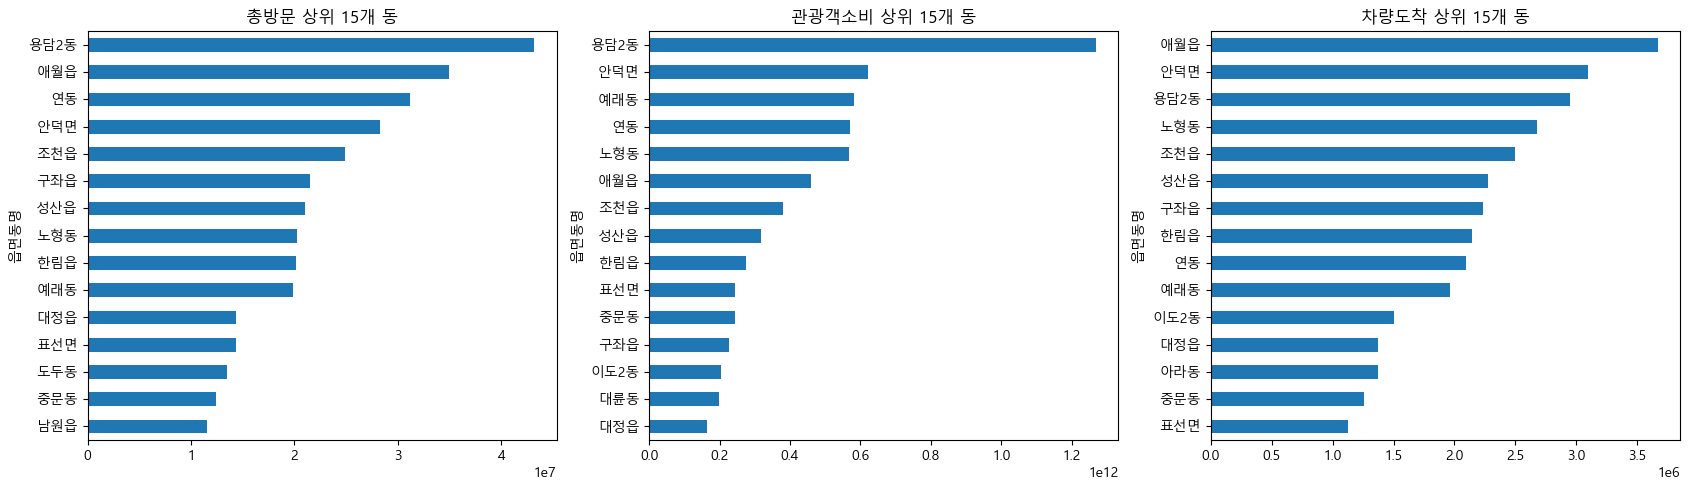

      총방문  관광객소비  차량도착
시                     
서귀포시 0.37   0.37  0.37
제주시  0.63   0.63  0.63


In [6]:
fig, ax = plt.subplots(1, 3, figsize=(17, 5))
for a_, col in zip(ax, ['총방문','관광객소비','차량도착']):
    dong.set_index('읍면동명')[col].nlargest(15).sort_values().plot.barh(ax=a_, title=f'{col} 상위 15개 동')
plt.tight_layout(); plt.show()
print(dong.groupby('시')[['총방문','관광객소비','차량도착']].sum().div(dong[['총방문','관광객소비','차량도착']].sum()).round(3))

## 6. EDA ③ 소비 구조 (관광객구분 × 업종)

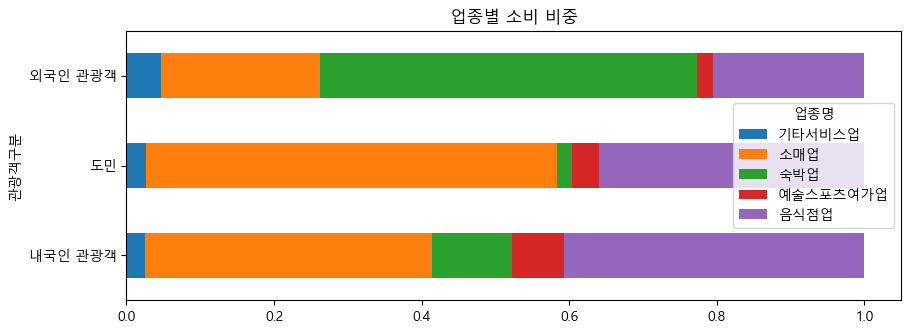

관광객구분
내국인 관광객   35,181.00
도민        25,693.00
외국인 관광객   89,301.00
dtype: float64


In [7]:
mix = s.pivot_table(index='관광객구분', columns='업종명', values='소비금액', aggfunc='sum')
mix.div(mix.sum(axis=1), axis=0).plot.barh(stacked=True, figsize=(10, 3.5), title='업종별 소비 비중')
plt.show()
print((s.groupby('관광객구분')['소비금액'].sum() / s.groupby('관광객구분')['이용건수'].sum()).round(0))   # 건당 소비액

## 7. EDA ④ 통과형 식별: 트래픽 vs 소비

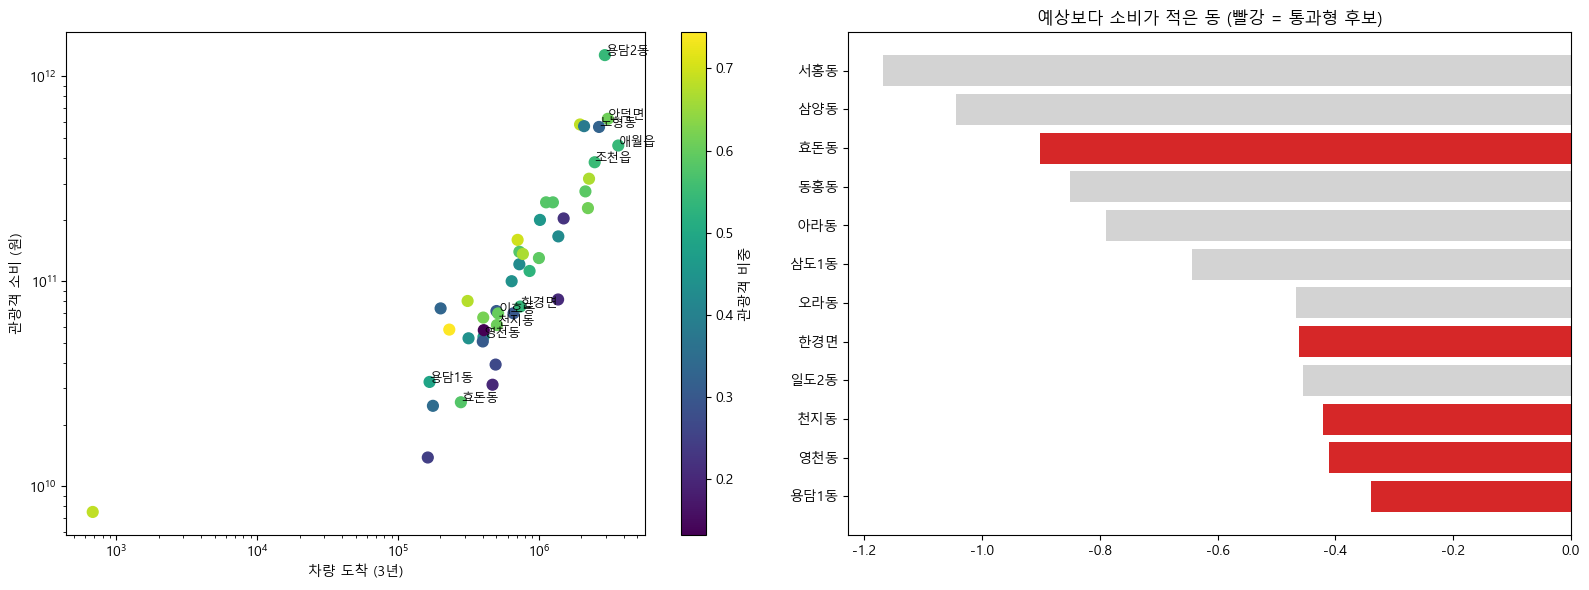

       시  읍면동명  관광객비중  소비잔차  통과지수  트레킹체험비중  숙박시설수  상권후보장소수  주차장수  주차인프라
14  서귀포시   효돈동   0.58 -0.90  0.07     0.01     29     7.00  4.00  47.75
41   제주시   한경면   0.54 -0.46  0.12     0.26    366    12.00 20.00  25.05
13  서귀포시   천지동   0.61 -0.42  0.09     0.24     34     5.00   NaN    NaN
8   서귀포시   영천동   0.46 -0.41  0.05     0.25     41     7.00   NaN    NaN
31   제주시  용담1동   0.49 -0.34 -0.07     0.01      6     8.00 31.00   9.45
35   제주시   이호동   0.60 -0.30  0.07     0.01     43     5.00 12.00  18.67


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sc = ax[0].scatter(dong['차량도착'], dong['관광객소비'], c=dong['관광객비중'], cmap='viridis', s=60)
ax[0].set_xscale('log'); ax[0].set_yscale('log'); ax[0].set_xlabel('차량 도착 (3년)'); ax[0].set_ylabel('관광객 소비 (원)')
plt.colorbar(sc, ax=ax[0], label='관광객 비중')
for _, r in dong[dong['통과후보'] | (dong['차량도착'] > dong['차량도착'].quantile(0.9))].iterrows():
    ax[0].annotate(r['읍면동명'], (r['차량도착'], r['관광객소비']), fontsize=9)
d_ = dong.sort_values('소비잔차').head(12).iloc[::-1]
ax[1].barh(d_['읍면동명'], d_['소비잔차'], color=np.where(d_['통과후보'], 'tab:red', 'lightgray'))
ax[1].set_title('예상보다 소비가 적은 동 (빨강 = 통과형 후보)'); plt.tight_layout(); plt.show()
cols = ['시','읍면동명','관광객비중','소비잔차','통과지수','트레킹체험비중','숙박시설수','상권후보장소수','주차장수','주차인프라']
print(dong[dong['통과후보']][cols].sort_values('소비잔차').round(2).to_string())

## 8. EDA ⑤ 트레킹·체험 패턴

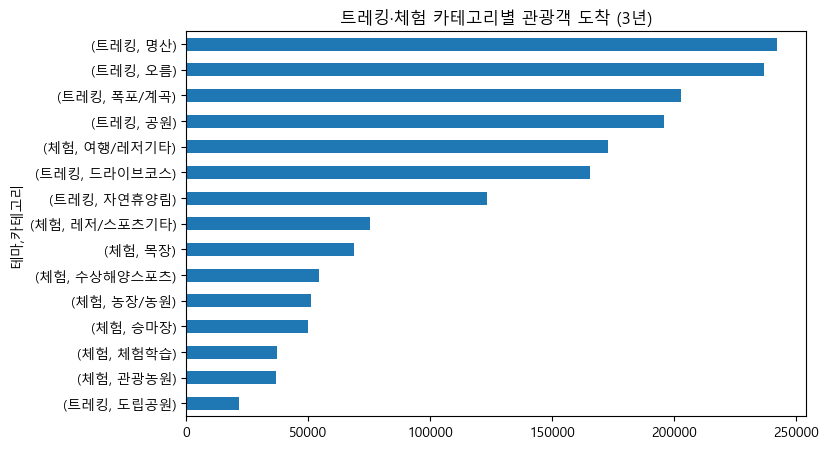

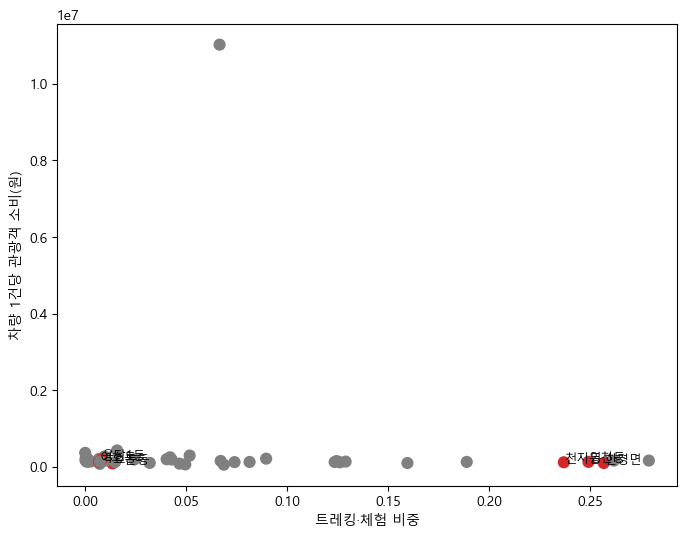

통과후보             False      True 
소비_기타서비스업         0.04       0.01
소비_소매업            0.35       0.37
소비_숙박업            0.14       0.05
소비_예술스포츠여가업       0.06       0.10
소비_음식점업           0.42       0.47
트레킹체험비중           0.06       0.13
건당소비         36,070.25  34,712.70
도착당소비       466,796.29 129,276.45
숙박시설수           139.86      86.50
주차인프라            39.22      25.23
상권후보장소수          20.44       7.33


In [9]:
tc = p[p['테마'] != '기타'].groupby(['테마','카테고리'])['관광객도착'].sum().sort_values().tail(15)
tc.plot.barh(figsize=(8, 5), title='트레킹·체험 카테고리별 관광객 도착 (3년)'); plt.show()
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(dong['트레킹체험비중'], dong['도착당소비'], c=np.where(dong['통과후보'], 'tab:red', 'gray'), s=60)
for _, r in dong[dong['통과후보']].iterrows(): ax.annotate(r['읍면동명'], (r['트레킹체험비중'], r['도착당소비']), fontsize=9)
ax.set_xlabel('트레킹·체험 비중'); ax.set_ylabel('차량 1건당 관광객 소비(원)'); plt.show()
biz = [c_ for c_ in panel.columns if c_.startswith('소비_')]
bz = panel.groupby('읍면동명')[biz].sum(); bz = bz.div(bz.sum(axis=1), axis=0)
cmp_cols = biz + ['트레킹체험비중','건당소비','도착당소비','숙박시설수','주차인프라','상권후보장소수']
print(dong.set_index('읍면동명').join(bz).groupby('통과후보')[cmp_cols].mean().round(2).T)   # 후보 vs 나머지

## 9. EDA ⑥ 파생변수 상관관계

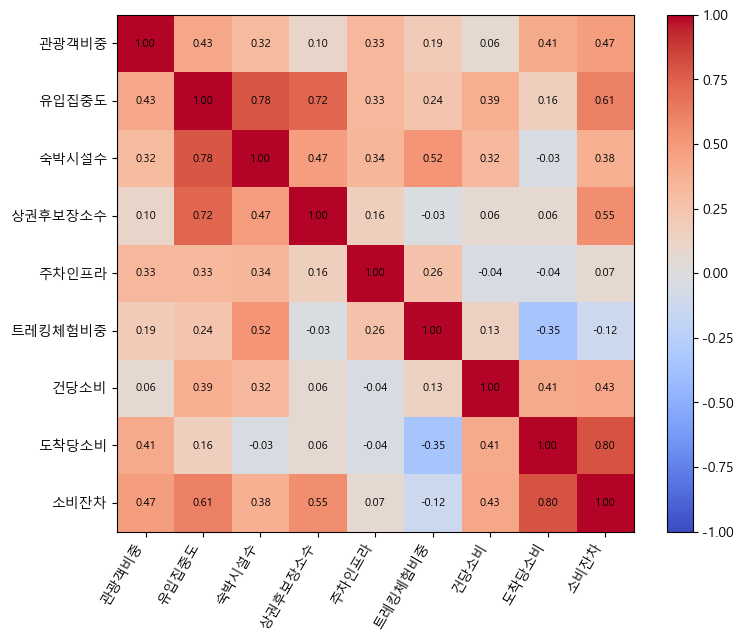

In [10]:
vars_ = ['관광객비중','유입집중도','숙박시설수','상권후보장소수','주차인프라','트레킹체험비중','건당소비','도착당소비','소비잔차']
cm = dong[vars_].corr(method='spearman')
fig, ax = plt.subplots(figsize=(8, 6.5)); im = ax.imshow(cm, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(vars_))); ax.set_xticklabels(vars_, rotation=60, ha='right'); ax.set_yticks(range(len(vars_))); ax.set_yticklabels(vars_)
for i in range(len(vars_)):
    for j in range(len(vars_)): ax.text(j, i, f'{cm.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im); plt.tight_layout(); plt.show()

## 10. 후보 동 심층 분석 (동 이름만 바꿔서 반복 사용)


===== 한경면 =====
[트레킹·체험 카테고리]
             장소수  관광객도착
테마  카테고리               
트레킹 드라이브코스     2  48783
    공원         5  15256
    명산         3   8002
체험  여행/레저기타    5   6449
트레킹 전망대        1   6194
체험  수상해양스포츠    5   6038
    낚시        12   5160
트레킹 오름         5   2296
[관광객 도착 상위 장소]
목적지명        카테고리  
신창풍차해안도로    드라이브코스    48389
산양큰엉곶       관광명소기타    18562
라온GC        골프장       10825
하나로마트/한경농협  대형슈퍼      10650
제주현대미술관     미술관        8581
환상숲곶자왈공원    공원         8556
수월봉         명산         7705
수월봉지질트레일    관광명소기타     6881
Name: 관광객도착, dtype: int64
[업종별 관광객 도착 1건당 소비 순위 (43개 동 중, 1=가장 높음)]
소비_기타서비스업      39
소비_소매업         37
소비_숙박업         40
소비_예술스포츠여가업     7
소비_음식점업        37
Name: 한경면, dtype: int64
[도민소비/관광객소비] 1.07 (전체 중앙값 1.1 )


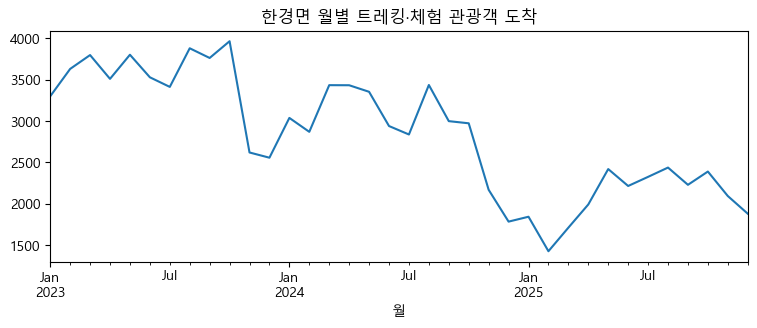


===== 천지동 =====
[트레킹·체험 카테고리]
              장소수  관광객도착
테마  카테고리                
트레킹 폭포/계곡       2  66877
    공원          4   2850
    도립공원        1   1984
체험  낚시          2    372
    수상해양스포츠     3    354
트레킹 전망대         1     39
체험  레저/스포츠기타    1     31
    농장/농원       1     21
[관광객 도착 상위 장소]
목적지명       카테고리  
천지연폭포      폭포/계곡     66877
천지연공영주차장   주차장       21299
신신호텔/천지연점  호텔        16532
외돌개공영주차장   주차장       13337
서귀포유람선     항구        12810
네거리식당      한식        11936
새연교        관광명소기타    11028
서귀포잠수함     관광명소기타    11023
Name: 관광객도착, dtype: int64
[업종별 관광객 도착 1건당 소비 순위 (43개 동 중, 1=가장 높음)]
소비_기타서비스업      35
소비_소매업         40
소비_숙박업         22
소비_예술스포츠여가업    37
소비_음식점업        27
Name: 천지동, dtype: int64
[도민소비/관광객소비] 1.1 (전체 중앙값 1.1 )


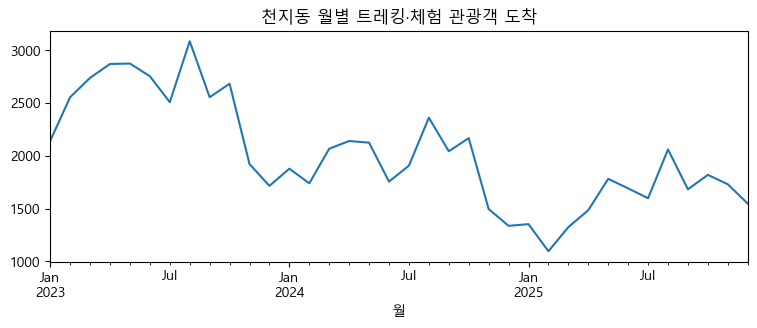


===== 영천동 =====
[트레킹·체험 카테고리]
              장소수  관광객도착
테마  카테고리                
체험  레저/스포츠기타    2  24477
트레킹 폭포/계곡       1  12115
    국립공원        1   8632
체험  여행/레저기타     2    653
    체험학습        2    336
    낚시          1    219
    체험농가        1    124
트레킹 명산          2     92
[관광객 도착 상위 장소]
목적지명          카테고리    
윈드1947카트테마파크  레저/스포츠기타    24463
더큐브리조트/제주     콘도/리조트      15824
하나로마트/서귀포농협   대형슈퍼         9264
한라산국립공원       국립공원         8632
은희네해장국/서귀포점   한식           8213
벨룸리조트         콘도/리조트       8017
원앙폭포          폭포/계곡        6346
상효원수목원        동식물원         6190
Name: 관광객도착, dtype: int64
[업종별 관광객 도착 1건당 소비 순위 (43개 동 중, 1=가장 높음)]
소비_기타서비스업      43
소비_소매업         15
소비_숙박업         21
소비_예술스포츠여가업     6
소비_음식점업        41
Name: 영천동, dtype: int64
[도민소비/관광객소비] 3.47 (전체 중앙값 1.1 )


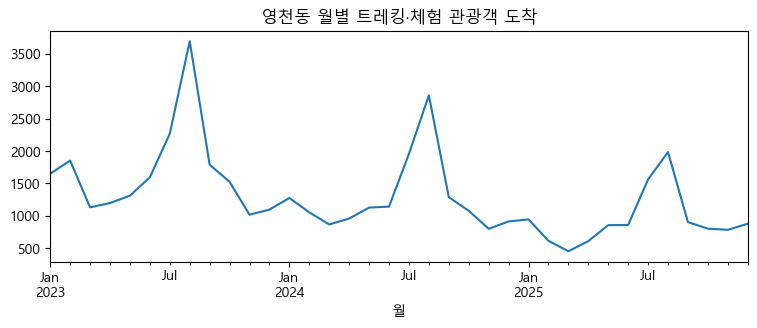

In [11]:
def deep_dive(name):
    q = p[p['읍면동명'] == name]
    biz_ = [c_ for c_ in panel.columns if c_.startswith('소비_')]
    per = panel.groupby('읍면동명')[biz_].sum().div(dong.set_index('읍면동명')['관광객도착_전체'], axis=0)
    print(f'\n===== {name} =====')
    print('[트레킹·체험 카테고리]')
    print(q[q['테마'] != '기타'].groupby(['테마','카테고리']).agg(장소수=('목적지주소','nunique'), 관광객도착=('관광객도착','sum'))
            .sort_values('관광객도착', ascending=False).head(8))
    print('[관광객 도착 상위 장소]')
    print(q.groupby(['목적지명','카테고리'])['관광객도착'].sum().sort_values(ascending=False).head(8))
    print('[업종별 관광객 도착 1건당 소비 순위 (43개 동 중, 1=가장 높음)]')
    print(per.rank(ascending=False).loc[name].astype(int))
    d_ = dong.set_index('읍면동명')
    print('[도민소비/관광객소비]', round(d_.loc[name,'도민소비'] / d_.loc[name,'관광객소비'], 2), '(전체 중앙값', round((d_['도민소비']/d_['관광객소비']).median(), 2), ')')
    mm = panel[panel['읍면동명'] == name].set_index('월')
    (mm['관광객도착_트레킹'] + mm['관광객도착_체험']).plot(title=f'{name} 월별 트레킹·체험 관광객 도착', figsize=(9, 3)); plt.show()

for n in ['한경면', '천지동', '영천동']:
    deep_dive(n)

## 11. 미스매치 지수 (Mismatch Index = Z_traffic - Z_spending)

Z_traffic ↔ Z_spending 상관: 0.82
{'정상': 35, '소비 증발': 6, '소비 집약': 2}
--- 소비 증발 상위 (MI)
       시  읍면동명  관광객비중  Z_traffic  Z_spending   MI  MI_건수  MI_로그  MI_구분
39   제주시   애월읍   0.54       2.82        1.13 1.69   0.97  -0.06  소비 증발
17   제주시   구좌읍   0.61       1.26        0.15 1.12   0.58   0.23  소비 증발
42   제주시   한림읍   0.59       1.17        0.35 0.82   0.43   0.03  소비 증발
27   제주시   아라동   0.20       0.33       -0.48 0.80   0.49   0.83  소비 증발
1   서귀포시   성산읍   0.67       1.31        0.52 0.78   0.34  -0.06  소비 증발
19   제주시   조천읍   0.55       1.55        0.80 0.75   0.37  -0.17  소비 증발
15  서귀포시   대정읍   0.42       0.33       -0.12 0.45   0.23   0.17     정상
34   제주시  이도2동   0.22       0.47        0.04 0.43   0.24   0.05     정상
--- 소비 집약 상위 (MI)
       시  읍면동명  관광객비중  Z_traffic  Z_spending    MI  MI_건수  MI_로그  MI_구분
32   제주시  용담2동   0.54       2.04        4.58 -2.55  -2.27  -1.16  소비 집약
9   서귀포시   예래동   0.69       0.97        1.66 -0.69   0.63  -0.74  소비 집약
28   제주시    연동   0.38       1.12        1.

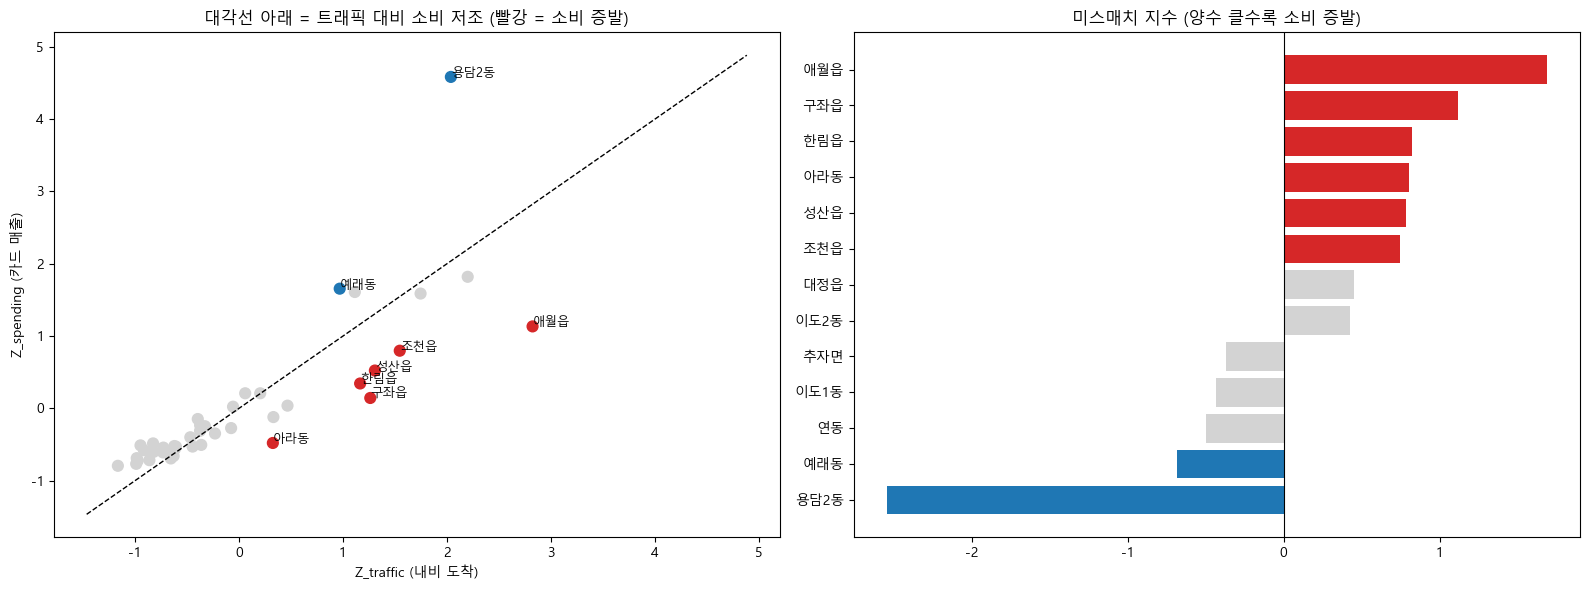

In [12]:
z = lambda x: (x - x.mean()) / x.std(ddof=0)                  # 평균 0, 표준편차 1
mi = dong[['시','읍면동명','관광객비중']].copy()
mi['Z_traffic']   = z(dong['차량도착'])                       # 내비 도착 건수
mi['Z_spending']  = z(dong['관광객소비'])                     # 카드 매출액 (관광객)
mi['Z_spend_cnt'] = z(dong['관광객이용건수'])                 # 카드 결제 건수 (대안)
mi['MI']       = mi['Z_traffic'] - mi['Z_spending']           # ★ 기본 미스매치 지수 (매출액 기준)
mi['MI_건수']  = mi['Z_traffic'] - mi['Z_spend_cnt']          # 결제 건수 기준
mi['MI_로그']  = z(np.log(dong['차량도착'])) - z(np.log(dong['관광객소비']))   # 로그 변환판 (치우친 분포 보정)

CUT = 1.0   # 지수의 표준편차 몇 배 이상이면 '매우 크다'로 볼지 (조정 가능)
for col in ['MI', 'MI_건수', 'MI_로그']:
    sd = mi[col].std()
    mi[col + '_구분'] = np.select([mi[col] >= CUT*sd, mi[col] <= -CUT*sd], ['소비 증발', '소비 집약'], '정상')

print('Z_traffic ↔ Z_spending 상관:', round(mi['Z_traffic'].corr(mi['Z_spending']), 2))
print(mi['MI_구분'].value_counts().to_dict())
show = ['시','읍면동명','관광객비중','Z_traffic','Z_spending','MI','MI_건수','MI_로그','MI_구분']
print('--- 소비 증발 상위 (MI)');  print(mi.sort_values('MI', ascending=False)[show].head(8).round(2).to_string())
print('--- 소비 집약 상위 (MI)');  print(mi.sort_values('MI')[show].head(5).round(2).to_string())
print('--- 소비 증발 상위 (로그판)'); print(mi.sort_values('MI_로그', ascending=False)[show].head(8).round(2).to_string())
print('MI 방식 간 순위상관:'); print(mi[['MI','MI_건수','MI_로그']].corr(method='spearman').round(2))

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
col_map = {'소비 증발':'tab:red', '정상':'lightgray', '소비 집약':'tab:blue'}
ax[0].scatter(mi['Z_traffic'], mi['Z_spending'], c=mi['MI_구분'].map(col_map), s=60)
lim = [min(mi['Z_traffic'].min(), mi['Z_spending'].min()) - .3, max(mi['Z_traffic'].max(), mi['Z_spending'].max()) + .3]
ax[0].plot(lim, lim, 'k--', lw=1); ax[0].set_xlabel('Z_traffic (내비 도착)'); ax[0].set_ylabel('Z_spending (카드 매출)')
ax[0].set_title('대각선 아래 = 트래픽 대비 소비 저조 (빨강 = 소비 증발)')
for _, r in mi[mi['MI_구분'] != '정상'].iterrows(): ax[0].annotate(r['읍면동명'], (r['Z_traffic'], r['Z_spending']), fontsize=9)
t_ = pd.concat([mi.sort_values('MI').head(5), mi.sort_values('MI').tail(8)])
ax[1].barh(t_['읍면동명'], t_['MI'], color=t_['MI_구분'].map(col_map)); ax[1].axvline(0, color='k', lw=.8)
ax[1].set_title('미스매치 지수 (양수 클수록 소비 증발)'); plt.tight_layout(); plt.show()
mi.to_csv('mismatch_index.csv', index=False, encoding='utf-8-sig')